# 02 – Feature Engineering

> **Thành viên phụ trách:** Thành viên 2  
> **Bài báo liên quan:** TimeMixer: Decomposable Multiscale Mixing for Time Series Forecasting (ICLR 2024)

Notebook này thực hiện toàn bộ pipeline feature engineering:

| Bước | Nội dung |
|------|----------|
| 1 | Cài đặt thư viện & Load dữ liệu thô (`hour.csv`) |
| 2 | Kiểm tra missing values |
| 3 | Kiểm tra tần suất lấy mẫu (sampling regularity) |
| 4 | Xử lý outlier (Winsorization Q1–Q99) |
| 5 | Tạo biến thời gian: `hour`, `day_of_week`, `month`, `is_weekend` |
| 6 | Tạo Fourier features: sin/cos chu kỳ giờ, ngày, tháng |
| 7 | Tạo Lag features: `lag_1`, `lag_24`, `lag_168` |
| 8 | Tạo Rolling features: `rolling_mean_24`, `rolling_std_24` |
| 9 | Loại bỏ cột gây data leakage |
| 10 | Chia Train / Val / Test theo thứ tự thời gian (70/15/15) |
| 11 | Chuẩn hóa dữ liệu (StandardScaler fit trên train) |
| 12 | Phân tích tương quan & visualize |
| 13 | Lưu file `data/processed/bike_sharing_processed.csv` |

**Liên hệ với TimeMixer:**  
- Fourier features ↔ phân rã mùa vụ đa thang đo (PDM)  
- Lag features (1h, 24h, 168h) ↔ đa thang đo lịch sử của TimeMixer  
- Rolling mean ↔ làm mượt xu hướng trong PDM

## Cell 1 – Cài đặt thư viện (chỉ chạy lần đầu)

In [1]:
import subprocess, sys

PACKAGES = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"]

for pkg in PACKAGES:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
        print(f"✓ {pkg} đã có sẵn")
    except ImportError:
        print(f"⚙ Đang cài {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"✓ {pkg} đã cài xong")

print("\n✅ Tất cả thư viện đã sẵn sàng!")

✓ numpy đã có sẵn


✓ pandas đã có sẵn


✓ matplotlib đã có sẵn


✓ seaborn đã có sẵn


✓ scikit-learn đã có sẵn

✅ Tất cả thư viện đã sẵn sàng!


## Cell 2 – Import & cấu hình

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Đường dẫn ──────────────────────────────────────────────────────────────
# Notebook nằm ở notebooks/, ROOT là thư mục cha
NOTEBOOK_DIR = os.path.abspath("")
ROOT = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == "notebooks" else NOTEBOOK_DIR

RAW_PATH       = os.path.join(ROOT, "data", "raw",       "hour.csv")
PROCESSED_PATH = os.path.join(ROOT, "data", "processed", "bike_sharing_processed.csv")
FIGURES_DIR    = os.path.join(ROOT, "figures")

os.makedirs(os.path.join(ROOT, "data", "processed"), exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_palette("tab10")

print(f"ROOT: {ROOT}")
print(f"RAW : {RAW_PATH}")
print(f"OUT : {PROCESSED_PATH}")

ROOT: C:\Users\ADMIN\Downloads\time-series-group-06-main\time-series-group-06-main
RAW : C:\Users\ADMIN\Downloads\time-series-group-06-main\time-series-group-06-main\data\raw\hour.csv
OUT : C:\Users\ADMIN\Downloads\time-series-group-06-main\time-series-group-06-main\data\processed\bike_sharing_processed.csv


## Cell 3 – Định nghĩa các hàm Feature Engineering

*(Tương đương `src/features.py` — viết inline để notebook chạy độc lập)*

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# 3A. Datetime
# ════════════════════════════════════════════════════════════════════════════
def add_datetime_column(df):
    """Tạo cột datetime từ dteday + hr."""
    result = df.copy()
    result["datetime"] = (
        pd.to_datetime(result["dteday"]) +
        pd.to_timedelta(result["hr"], unit="h")
    )
    return result.sort_values("datetime").reset_index(drop=True)


# ════════════════════════════════════════════════════════════════════════════
# 3B. Calendar / Time features
# ════════════════════════════════════════════════════════════════════════════
def add_time_features(df):
    """Thêm biến thời gian: hour, day_of_week, month, is_weekend."""
    result = df.copy()
    result["hour"]       = result["datetime"].dt.hour
    result["day_of_week"]= result["datetime"].dt.dayofweek   # 0=T2 … 6=CN
    result["month"]      = result["datetime"].dt.month
    result["is_weekend"] = result["day_of_week"].isin([5, 6]).astype(int)
    return result


# ════════════════════════════════════════════════════════════════════════════
# 3C. Fourier / Cyclic features
# ════════════════════════════════════════════════════════════════════════════
def add_fourier_features(df):
    """Thêm Fourier features sin/cos cho giờ, ngày trong tuần, tháng."""
    result = df.copy()
    result["hour_sin"]    = np.sin(2 * np.pi * result["hour"]        / 24)
    result["hour_cos"]    = np.cos(2 * np.pi * result["hour"]        / 24)
    result["weekday_sin"] = np.sin(2 * np.pi * result["day_of_week"] / 7)
    result["weekday_cos"] = np.cos(2 * np.pi * result["day_of_week"] / 7)
    result["month_sin"]   = np.sin(2 * np.pi * result["month"]       / 12)
    result["month_cos"]   = np.cos(2 * np.pi * result["month"]       / 12)
    return result


# ════════════════════════════════════════════════════════════════════════════
# 3D. Lag & Rolling features
# ════════════════════════════════════════════════════════════════════════════
def add_lag_features(df, target="cnt"):
    """Thêm lag (1h, 24h, 168h) và rolling (mean/std 24h) cho target.
    Dùng shift(1) cho rolling để tránh data leakage.
    """
    result = df.copy()
    result["lag_1"]          = result[target].shift(1)
    result["lag_24"]         = result[target].shift(24)
    result["lag_168"]        = result[target].shift(168)
    result["rolling_mean_24"]= result[target].shift(1).rolling(24).mean()
    result["rolling_std_24"] = result[target].shift(1).rolling(24).std()
    return result


# ════════════════════════════════════════════════════════════════════════════
# 3E. Outlier handling
# ════════════════════════════════════════════════════════════════════════════
def remove_outliers_iqr(df, target="cnt", lower_q=0.01, upper_q=0.99):
    """Winsorization: clip target về [Q_low, Q_high], giữ nguyên số hàng."""
    result = df.copy()
    low  = result[target].quantile(lower_q)
    high = result[target].quantile(upper_q)
    n_clip = ((result[target] < low) | (result[target] > high)).sum()
    result[target] = result[target].clip(low, high)
    print(f"Winsorization '{target}': clip {n_clip} rows → [{low:.1f}, {high:.1f}]")
    return result


# ════════════════════════════════════════════════════════════════════════════
# 3F. Train / Val / Test split
# ════════════════════════════════════════════════════════════════════════════
def split_data(df, train_ratio=0.70, val_ratio=0.15):
    """Chia chronologically – KHÔNG xáo trộn để tránh data leakage."""
    n         = len(df)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))
    df_train  = df.iloc[:train_end].copy()
    df_val    = df.iloc[train_end:val_end].copy()
    df_test   = df.iloc[val_end:].copy()
    print(f"Split (n={n}):  Train={len(df_train)} ({len(df_train)/n*100:.1f}%)  "
          f"Val={len(df_val)} ({len(df_val)/n*100:.1f}%)  "
          f"Test={len(df_test)} ({len(df_test)/n*100:.1f}%)")
    return df_train, df_val, df_test


# ════════════════════════════════════════════════════════════════════════════
# 3G. Normalization
# ════════════════════════════════════════════════════════════════════════════
def normalize_features(df_train, df_val, df_test, feature_cols):
    """StandardScaler: fit trên train, transform cả 3 tập."""
    scaler    = StandardScaler()
    tr, va, te = df_train.copy(), df_val.copy(), df_test.copy()
    tr[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    va[feature_cols] = scaler.transform(df_val[feature_cols])
    te[feature_cols] = scaler.transform(df_test[feature_cols])
    return tr, va, te, scaler


print("✓ Tất cả hàm feature engineering đã được định nghĩa.")

✓ Tất cả hàm feature engineering đã được định nghĩa.


## Cell 4 – Load dữ liệu thô

In [4]:
df_raw = pd.read_csv(RAW_PATH)

print(f"Shape       : {df_raw.shape}")
print(f"Thời gian   : {df_raw['dteday'].min()}  →  {df_raw['dteday'].max()}")
print(f"Columns     : {list(df_raw.columns)}")
print()

# Kiểm tra missing values
missing = df_raw.isnull().sum()
if missing.any():
    print("⚠ Missing values:")
    print(missing[missing > 0])
else:
    print("✓ Không có missing value.")

df_raw.head()

Shape       : (17379, 17)
Thời gian   : 2011-01-01  →  2012-12-31
Columns     : ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

✓ Không có missing value.


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
# Thống kê mô tả
df_raw[["temp", "atemp", "hum", "windspeed", "cnt"]].describe().round(3)

,temp,atemp,hum,windspeed,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000
mean,0.497,0.476,0.627,0.190,189.463
std,0.193,0.172,0.193,0.122,181.388
min,0.020,0.000,0.000,0.000,1.000
25%,0.340,0.333,0.480,0.104,40.000
50%,0.500,0.485,0.630,0.194,142.000
75%,0.660,0.621,0.780,0.254,281.000
max,1.000,1.000,1.000,0.851,977.000


## Cell 5 – Kiểm tra tần suất lấy mẫu (Sampling Regularity)

Dữ liệu `hour.csv` được ghi nhận theo giờ (hourly). Tuy nhiên, **không đảm bảo rằng mọi timestamp đều có mặt** — có thể thiếu một số giờ nhất định.

> **Notebook 01** (Thành viên 1) đã phát hiện **165 giờ bị thiếu** trong toàn bộ 2 năm dữ liệu.  
> Notebook này nhắc lại phát hiện đó và mô tả cách xử lý trong pipeline Feature Engineering.

### Cách xử lý đã chọn:
- **Nhóm KHÔNG nội suy (reindex + interpolate)** toàn bộ timeline để đơn giản hóa.
- Lag/Rolling features được tính theo **thứ tự hàng có sẵn** (không phải theo timestamp thực).
- Các hàng đầu bị NaN do lag features (tối thiểu 168 hàng cho `lag_168`) sẽ được **drop**.
- Hệ quả: nếu có timestamp bị thiếu, lag_24 có thể không phản ánh đúng "cùng giờ hôm qua" mà là giờ liền trước trong dữ liệu. Đây là trade-off chấp nhận được với bài này.

*(Nếu muốn chính xác hơn: reindex theo hourly timeline → forward fill hoặc interpolate → tính lag/rolling. Nhưng không bắt buộc với dataset này.)*

In [6]:
# Tạo cột datetime để kiểm tra
_df_check = df_raw.copy()
_df_check["datetime"] = pd.to_datetime(_df_check["dteday"]) + pd.to_timedelta(_df_check["hr"], unit="h")
_df_check = _df_check.sort_values("datetime").reset_index(drop=True)

# Khoảng thời gian lý thuyết
dt_min = _df_check["datetime"].min()
dt_max = _df_check["datetime"].max()
full_range = pd.date_range(start=dt_min, end=dt_max, freq="h")
n_expected = len(full_range)
n_actual   = len(_df_check)
n_missing  = n_expected - n_actual

print(f"Thời gian bắt đầu : {dt_min}")
print(f"Thời gian kết thúc: {dt_max}")
print(f"Số giờ lý thuyết  : {n_expected:,}")
print(f"Số hàng thực tế   : {n_actual:,}")
print(f"Số timestamp thiếu: {n_missing}")
print()

if n_missing > 0:
    missing_ts = full_range[~full_range.isin(_df_check["datetime"])]
    print(f"⚠ Có {n_missing} timestamp bị thiếu. Ví dụ 10 timestamp đầu:")
    print(missing_ts[:10].tolist())
    print()
    print("→ Xử lý: giữ nguyên thứ tự hàng có sẵn, tính lag/rolling theo hàng.")
    print("  Các hàng NaN đầu (do lag_168) sẽ bị drop sau khi tạo features.")
else:
    print("✓ Dữ liệu lấy mẫu đều, không có timestamp thiếu.")

# Kiểm tra khoảng cách giữa các timestamp liên tiếp
diffs = _df_check["datetime"].diff().dropna()
diff_counts = diffs.value_counts().head(5)
print("\nKhoảng cách giữa các timestamp (top 5):")
print(diff_counts.to_string())

Thời gian bắt đầu : 2011-01-01 00:00:00
Thời gian kết thúc: 2012-12-31 23:00:00
Số giờ lý thuyết  : 17,544
Số hàng thực tế   : 17,379
Số timestamp thiếu: 165

⚠ Có 165 timestamp bị thiếu. Ví dụ 10 timestamp đầu:
[Timestamp('2011-01-02 05:00:00'), Timestamp('2011-01-03 02:00:00'), Timestamp('2011-01-03 03:00:00'), Timestamp('2011-01-04 03:00:00'), Timestamp('2011-01-05 03:00:00'), Timestamp('2011-01-06 03:00:00'), Timestamp('2011-01-07 03:00:00'), Timestamp('2011-01-11 03:00:00'), Timestamp('2011-01-11 04:00:00'), Timestamp('2011-01-12 03:00:00')]

→ Xử lý: giữ nguyên thứ tự hàng có sẵn, tính lag/rolling theo hàng.
  Các hàng NaN đầu (do lag_168) sẽ bị drop sau khi tạo features.

Khoảng cách giữa các timestamp (top 5):
datetime
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 13:00:00        1
0 days 23:00:00        1


## Cell 6 – Xử lý Outlier (Winsorization)

Dùng **Winsorization** thay vì xóa hàng vì xóa hàng sẽ phá vỡ tính liên tục của chuỗi thời gian,
làm lag features bị sai.

Winsorization 'cnt': clip 332 rows → [2.0, 782.2]


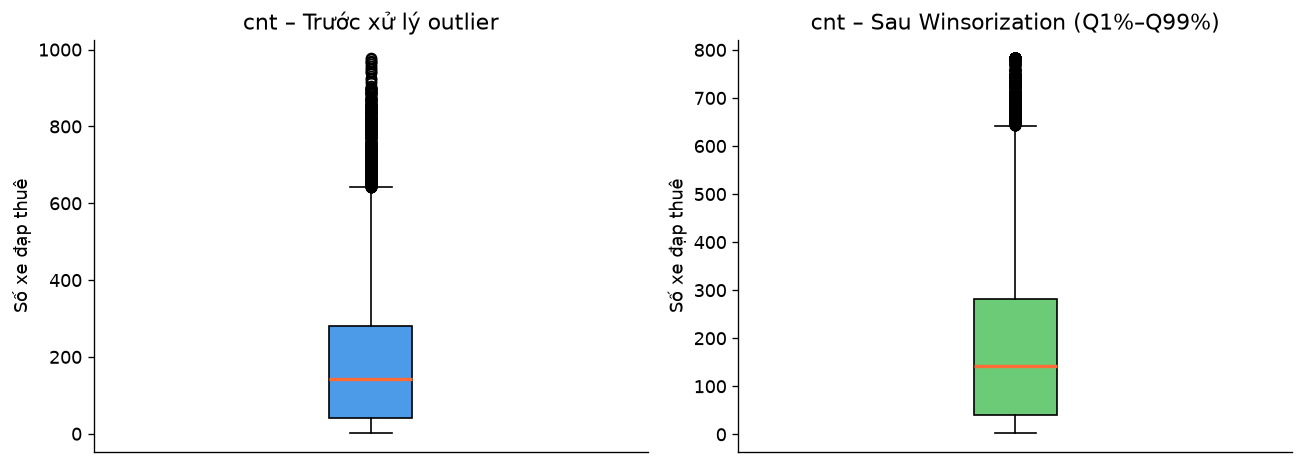

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Trước
axes[0].boxplot(df_raw["cnt"], patch_artist=True,
                boxprops=dict(facecolor="#4C9BE8"),
                medianprops=dict(color="#FF6B35", linewidth=2))
axes[0].set_title("cnt – Trước xử lý outlier")
axes[0].set_ylabel("Số xe đạp thuê")
axes[0].set_xticks([])

# Áp dụng Winsorization
df = remove_outliers_iqr(df_raw, target="cnt", lower_q=0.01, upper_q=0.99)

# Sau
axes[1].boxplot(df["cnt"], patch_artist=True,
                boxprops=dict(facecolor="#6BCB77"),
                medianprops=dict(color="#FF6B35", linewidth=2))
axes[1].set_title("cnt – Sau Winsorization (Q1%–Q99%)")
axes[1].set_ylabel("Số xe đạp thuê")
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_outlier_boxplot.png"), bbox_inches="tight")
plt.show()

## Cell 7 – Tạo biến thời gian

| Biến | Mô tả |
|------|--------|
| `hour` | Giờ trong ngày (0–23) |
| `day_of_week` | Ngày trong tuần (0=Thứ Hai … 6=Chủ Nhật) |
| `month` | Tháng (1–12) |
| `is_weekend` | 1 nếu thứ Bảy hoặc Chủ Nhật |

In [8]:
df = add_datetime_column(df)
df = add_time_features(df)

print("Kiểm tra time features (5 hàng đầu):")
df[["datetime", "hr", "hour", "day_of_week", "month", "is_weekend"]].head(10)

Kiểm tra time features (5 hàng đầu):


,datetime,hr,hour,day_of_week,month,is_weekend
0,2011-01-01 00:00:00,0,0,5,1,1
1,2011-01-01 01:00:00,1,1,5,1,1
2,2011-01-01 02:00:00,2,2,5,1,1
3,2011-01-01 03:00:00,3,3,5,1,1
4,2011-01-01 04:00:00,4,4,5,1,1
5,2011-01-01 05:00:00,5,5,5,1,1
6,2011-01-01 06:00:00,6,6,5,1,1
7,2011-01-01 07:00:00,7,7,5,1,1
8,2011-01-01 08:00:00,8,8,5,1,1
9,2011-01-01 09:00:00,9,9,5,1,1


## Cell 8 – Tạo Fourier Features

Fourier features biểu diễn chu kỳ dưới dạng sin/cos giúp model nhận biết tính tuần hoàn
mà không bị "gián đoạn" ở ranh giới chu kỳ (ví dụ: giờ 23 và giờ 0 phải gần nhau).

| Feature | Công thức | Chu kỳ |
|---------|-----------|--------|
| `hour_sin`, `hour_cos` | sin/cos(2π·hour/24) | 24 giờ |
| `weekday_sin`, `weekday_cos` | sin/cos(2π·day/7) | 7 ngày |
| `month_sin`, `month_cos` | sin/cos(2π·month/12) | 12 tháng |

**Liên hệ TimeMixer:** Tương đương với cách PDM phân rã thành phần mùa vụ ở nhiều thang đo.

In [9]:
df = add_fourier_features(df)

# Sanity check: sin² + cos² phải = 1
for col, period in [("hour", 24), ("weekday", 7), ("month", 12)]:
    check = (df[f"{col}_sin"]**2 + df[f"{col}_cos"]**2).round(10)
    assert (check == 1.0).all(), f"Fail: {col}"
    print(f"✓ {col}_sin² + {col}_cos² = 1.0 (tất cả hàng)")

print()
fourier_cols = ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "month_sin", "month_cos"]
df[fourier_cols].head()

✓ hour_sin² + hour_cos² = 1.0 (tất cả hàng)
✓ weekday_sin² + weekday_cos² = 1.0 (tất cả hàng)
✓ month_sin² + month_cos² = 1.0 (tất cả hàng)



,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,0.000000,1.000000,-0.974928,-0.222521,0.5,0.866025
1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025
2,0.500000,0.866025,-0.974928,-0.222521,0.5,0.866025
3,0.707107,0.707107,-0.974928,-0.222521,0.5,0.866025
4,0.866025,0.500000,-0.974928,-0.222521,0.5,0.866025


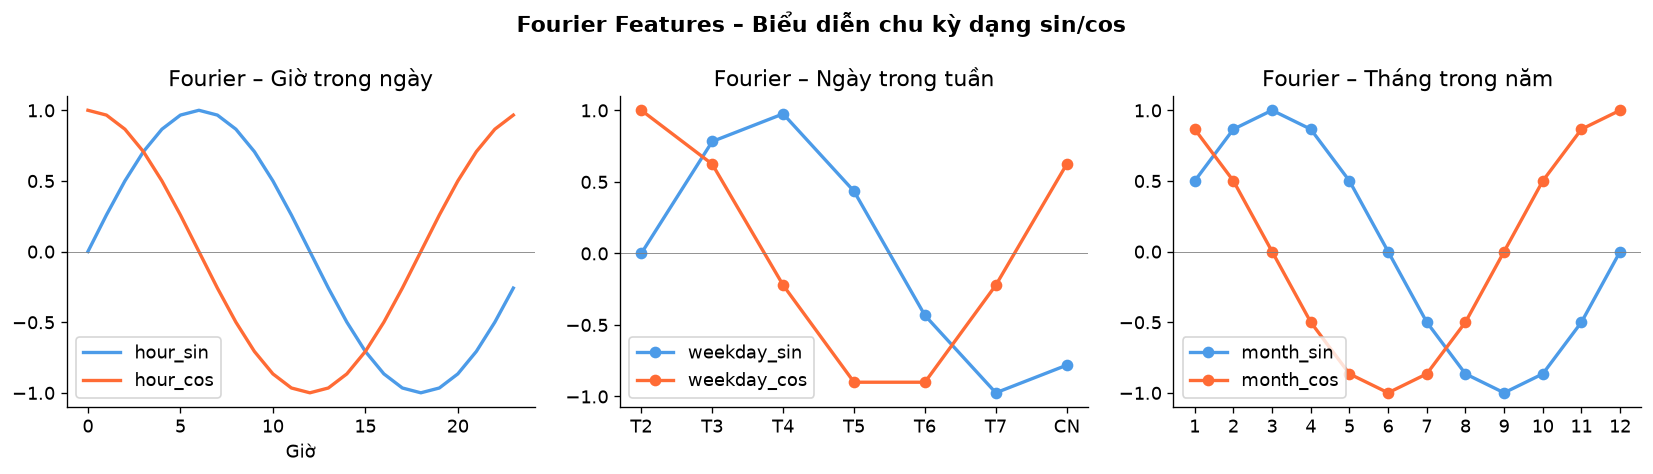

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Giờ
h = np.arange(24)
axes[0].plot(h, np.sin(2*np.pi*h/24), color="#4C9BE8", lw=2, label="hour_sin")
axes[0].plot(h, np.cos(2*np.pi*h/24), color="#FF6B35", lw=2, label="hour_cos")
axes[0].set_title("Fourier – Giờ trong ngày")
axes[0].set_xlabel("Giờ"); axes[0].legend(); axes[0].axhline(0, color="gray", lw=0.5)

# Ngày trong tuần
d = np.arange(7)
axes[1].plot(d, np.sin(2*np.pi*d/7), color="#4C9BE8", lw=2, marker="o", label="weekday_sin")
axes[1].plot(d, np.cos(2*np.pi*d/7), color="#FF6B35", lw=2, marker="o", label="weekday_cos")
axes[1].set_title("Fourier – Ngày trong tuần")
axes[1].set_xticks(d); axes[1].set_xticklabels(["T2","T3","T4","T5","T6","T7","CN"])
axes[1].legend(); axes[1].axhline(0, color="gray", lw=0.5)

# Tháng
m = np.arange(1, 13)
axes[2].plot(m, np.sin(2*np.pi*m/12), color="#4C9BE8", lw=2, marker="o", label="month_sin")
axes[2].plot(m, np.cos(2*np.pi*m/12), color="#FF6B35", lw=2, marker="o", label="month_cos")
axes[2].set_title("Fourier – Tháng trong năm")
axes[2].set_xticks(m); axes[2].legend(); axes[2].axhline(0, color="gray", lw=0.5)

plt.suptitle("Fourier Features – Biểu diễn chu kỳ dạng sin/cos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_fourier_features.png"), bbox_inches="tight")
plt.show()

## Cell 9 – Tạo Lag & Rolling Features

**Lag features** – nắm bắt chu kỳ ở các thang đo khác nhau (đa thang đo như TimeMixer):
- `lag_1` : giá trị 1 giờ trước → **fine scale**
- `lag_24` : cùng giờ hôm qua → **daily cycle**
- `lag_168`: cùng giờ tuần trước → **weekly cycle**

**Rolling features** (tính trên `shift(1)` để tránh data leakage):
- `rolling_mean_24`: trung bình 24 giờ → ước lượng xu hướng
- `rolling_std_24` : độ lệch chuẩn 24 giờ → mức biến động

> **Lưu ý về sampling regularity:** Vì dữ liệu có một số timestamp bị thiếu (~165 giờ),
> lag features được tính theo **thứ tự hàng** (row index) chứ không phải theo timestamp thực.
> Điều này là chấp nhận được với bài này. Nếu cần chính xác hơn: reindex theo hourly timeline
> rồi forward fill/interpolate trước khi tạo lag features.

In [11]:
df = add_lag_features(df, target="cnt")

lag_cols = ["cnt", "lag_1", "lag_24", "lag_168", "rolling_mean_24", "rolling_std_24"]
print("5 hàng đầu (NaN do chưa đủ lịch sử):")
print(df[lag_cols].head(10).to_string())
print()
print("NaN count:")
print(df[lag_cols].isnull().sum().to_string())

5 hàng đầu (NaN do chưa đủ lịch sử):
    cnt  lag_1  lag_24  lag_168  rolling_mean_24  rolling_std_24
0  16.0    NaN     NaN      NaN              NaN             NaN
1  40.0   16.0     NaN      NaN              NaN             NaN
2  32.0   40.0     NaN      NaN              NaN             NaN
3  13.0   32.0     NaN      NaN              NaN             NaN
4   2.0   13.0     NaN      NaN              NaN             NaN
5   2.0    2.0     NaN      NaN              NaN             NaN
6   2.0    2.0     NaN      NaN              NaN             NaN
7   3.0    2.0     NaN      NaN              NaN             NaN
8   8.0    3.0     NaN      NaN              NaN             NaN
9  14.0    8.0     NaN      NaN              NaN             NaN

NaN count:
cnt                  0
lag_1                1
lag_24              24
lag_168            168
rolling_mean_24     24
rolling_std_24      24


In [12]:
# Drop NaN rows (168 hàng đầu do lag_168)
n_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows trước drop NaN : {n_before:,}")
print(f"Rows sau drop NaN   : {len(df):,}")
print(f"Rows bị loại bỏ     : {n_before - len(df)} (do lag_168 cần 168 bước đầu)")

Rows trước drop NaN : 17,379
Rows sau drop NaN   : 17,211
Rows bị loại bỏ     : 168 (do lag_168 cần 168 bước đầu)


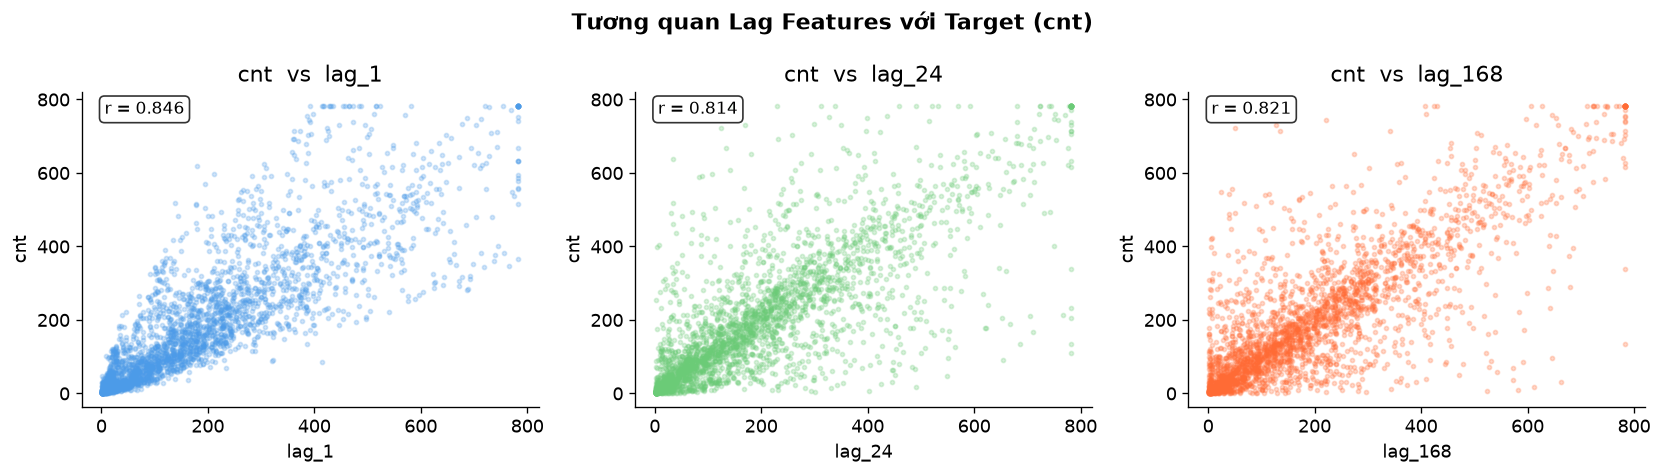

In [13]:
# Scatter: lag features vs cnt
sample = df.sample(n=min(3000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes,
    ["lag_1", "lag_24", "lag_168"],
    ["#4C9BE8", "#6BCB77", "#FF6B35"]):
    ax.scatter(sample[col], sample["cnt"], alpha=0.25, s=6, color=color)
    corr = df[col].corr(df["cnt"])
    ax.text(0.05, 0.93, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.set_xlabel(col); ax.set_ylabel("cnt")
    ax.set_title(f"cnt  vs  {col}")

plt.suptitle("Tương quan Lag Features với Target (cnt)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_lag_scatter.png"), bbox_inches="tight")
plt.show()

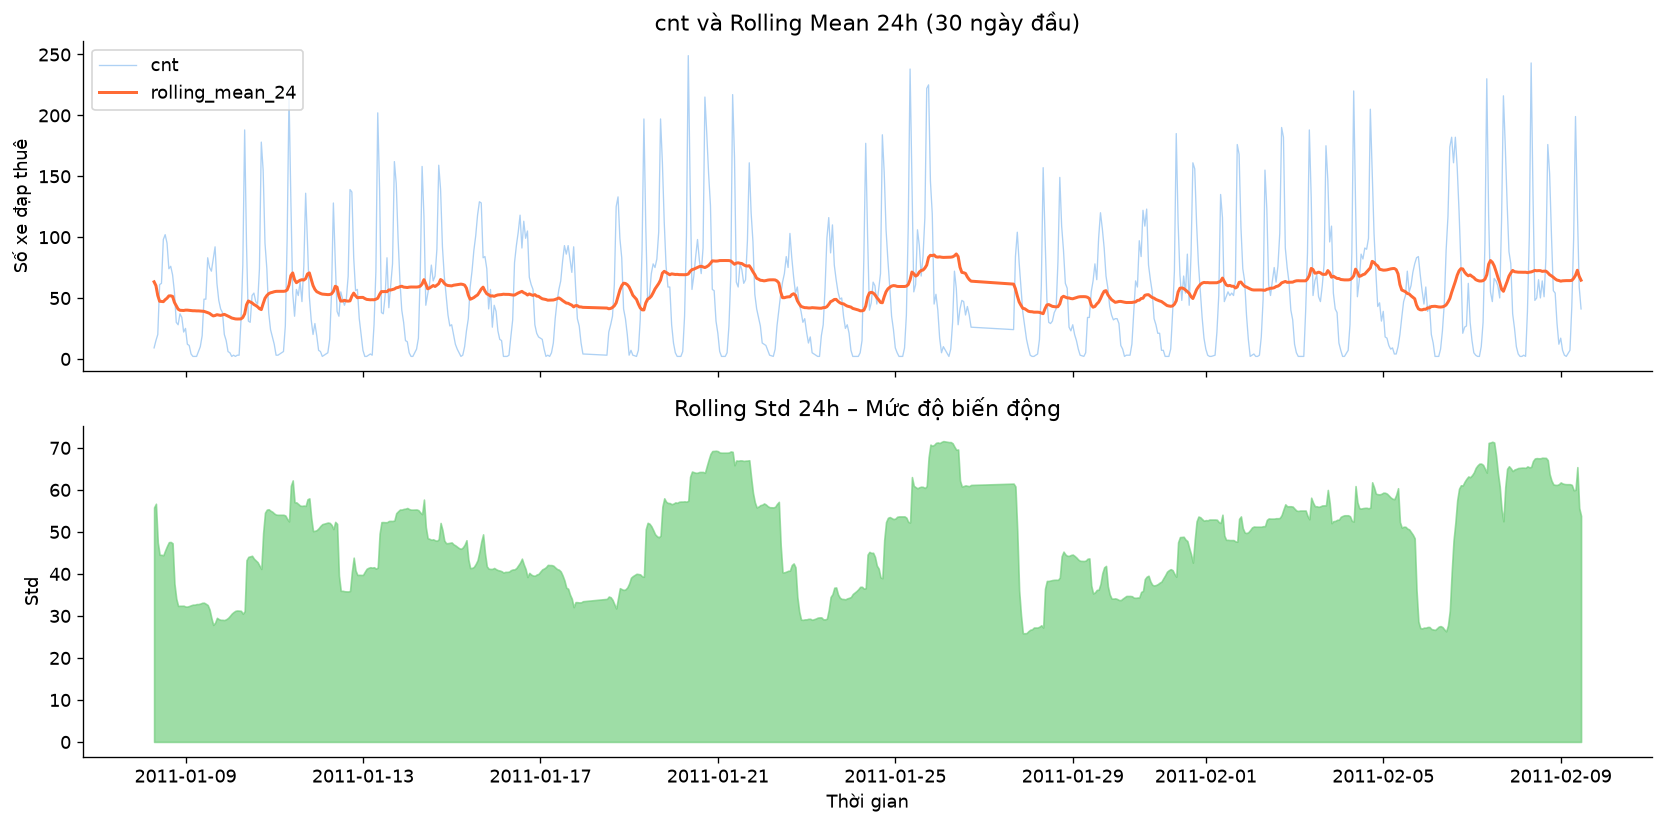

In [14]:
# Rolling features theo thời gian (30 ngày đầu)
plot_df = df[["datetime", "cnt", "rolling_mean_24", "rolling_std_24"]].iloc[:24*30]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(plot_df["datetime"], plot_df["cnt"],
             color="#4C9BE8", alpha=0.45, lw=0.8, label="cnt")
axes[0].plot(plot_df["datetime"], plot_df["rolling_mean_24"],
             color="#FF6B35", lw=1.8, label="rolling_mean_24")
axes[0].set_ylabel("Số xe đạp thuê"); axes[0].legend()
axes[0].set_title("cnt và Rolling Mean 24h (30 ngày đầu)")

axes[1].fill_between(plot_df["datetime"], 0, plot_df["rolling_std_24"],
                     color="#6BCB77", alpha=0.65)
axes[1].set_ylabel("Std"); axes[1].set_xlabel("Thời gian")
axes[1].set_title("Rolling Std 24h – Mức độ biến động")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_rolling_features.png"), bbox_inches="tight")
plt.show()

## Cell 10 – Loại bỏ cột gây Data Leakage

- `casual` + `registered` = `cnt` → **data leakage** nếu dùng làm input
- `dteday`, `instant` → không cần sau khi đã có `datetime` và biến thời gian

In [15]:
DROP_COLS = ["casual", "registered", "dteday", "instant"]
drop_existing = [c for c in DROP_COLS if c in df.columns]
df_processed = df.drop(columns=drop_existing)

print(f"Đã loại bỏ : {drop_existing}")
print(f"Shape còn lại: {df_processed.shape}")
print(f"\nCác cột ({len(df_processed.columns)}):")
for i, col in enumerate(df_processed.columns, 1):
    print(f"  {i:2d}. {col}")

Đã loại bỏ : ['casual', 'registered', 'dteday', 'instant']
Shape còn lại: (17211, 29)

Các cột (29):
   1. season
   2. yr
   3. mnth
   4. hr
   5. holiday
   6. weekday
   7. workingday
   8. weathersit
   9. temp
  10. atemp
  11. hum
  12. windspeed
  13. cnt
  14. datetime
  15. hour
  16. day_of_week
  17. month
  18. is_weekend
  19. hour_sin
  20. hour_cos
  21. weekday_sin
  22. weekday_cos
  23. month_sin
  24. month_cos
  25. lag_1
  26. lag_24
  27. lag_168
  28. rolling_mean_24
  29. rolling_std_24


## Cell 11 – Chia Train / Val / Test (70 / 15 / 15)

> **Quan trọng:** Chia theo **thứ tự thời gian**, KHÔNG shuffle.  
> Nếu shuffle ngẫu nhiên → thông tin tương lai lọt vào train qua lag features → **data leakage**.

In [16]:
df_train_raw, df_val_raw, df_test_raw = split_data(df_processed)

print()
print(f"Train: {df_train_raw['datetime'].min().date()}  →  {df_train_raw['datetime'].max().date()}")
print(f"Val  : {df_val_raw['datetime'].min().date()}  →  {df_val_raw['datetime'].max().date()}")
print(f"Test : {df_test_raw['datetime'].min().date()}  →  {df_test_raw['datetime'].max().date()}")

Split (n=17211):  Train=12047 (70.0%)  Val=2582 (15.0%)  Test=2582 (15.0%)

Train: 2011-01-08  →  2012-05-29
Val  : 2012-05-29  →  2012-09-13
Test : 2012-09-13  →  2012-12-31


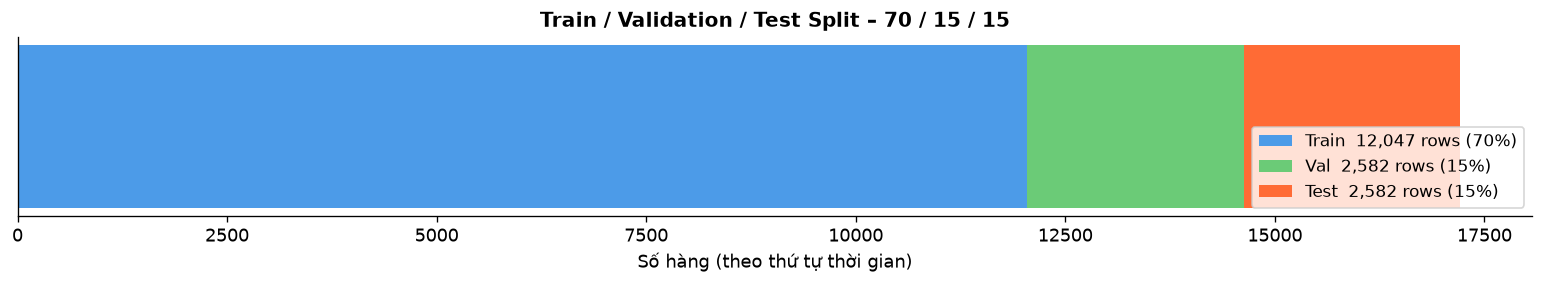

In [17]:
# Visualize timeline split
n_total = len(df_processed)
n_tr = len(df_train_raw); n_va = len(df_val_raw); n_te = len(df_test_raw)

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.barh(0, n_tr,             left=0,          color="#4C9BE8", height=0.5,
        label=f"Train  {n_tr:,} rows ({n_tr/n_total*100:.0f}%)")
ax.barh(0, n_va,             left=n_tr,        color="#6BCB77", height=0.5,
        label=f"Val  {n_va:,} rows ({n_va/n_total*100:.0f}%)")
ax.barh(0, n_te,             left=n_tr+n_va,   color="#FF6B35", height=0.5,
        label=f"Test  {n_te:,} rows ({n_te/n_total*100:.0f}%)")

ax.set_yticks([])
ax.set_xlabel("Số hàng (theo thứ tự thời gian)")
ax.set_title("Train / Validation / Test Split – 70 / 15 / 15", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_train_val_test_split.png"), bbox_inches="tight")
plt.show()

## Cell 12 – Chuẩn hóa dữ liệu (StandardScaler)

### Chiến lược chuẩn hóa

- **Fit ONLY trên tập train** → tránh information leakage từ val/test
- **Transform** cả 3 tập bằng cùng một scaler
- `cnt` (target) **không** đưa vào scaler ở đây; model sẽ xử lý riêng nếu cần

### Lưu ý về file `bike_sharing_processed.csv`

> **File `data/processed/bike_sharing_processed.csv` lưu dữ liệu ở dạng GIÁ TRỊ GỐC (chưa chuẩn hóa).**

Lý do:
1. **Tránh data leakage:** StandardScaler phải được fit chỉ trên tập train. Nếu lưu dữ liệu đã chuẩn hóa mà không kèm theo scaler, sẽ không thể tái tạo đúng.
2. **Linh hoạt:** Notebook model (`03_models.ipynb`) sẽ tự áp dụng chuẩn hóa phù hợp với từng mô hình.
3. **Dễ debug:** Giá trị gốc dễ đọc và kiểm tra hơn.

**Quy trình đúng trong bước huấn luyện:**
```python
# Trong notebook 03_models.ipynb:
df_all = pd.read_csv('data/processed/bike_sharing_processed.csv')
df_train = df_all[df_all['split'] == 'train']
df_val   = df_all[df_all['split'] == 'val']
df_test  = df_all[df_all['split'] == 'test']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)          # transform val
X_test_scaled  = scaler.transform(X_test)         # transform test
```

In [18]:
TARGET       = "cnt"
NON_FEATURE  = {TARGET, "datetime"}
feature_cols = [c for c in df_processed.columns if c not in NON_FEATURE]

print(f"Số feature columns: {len(feature_cols)}")
print(feature_cols)

Số feature columns: 27
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']


In [19]:
df_train, df_val, df_test, scaler = normalize_features(
    df_train_raw, df_val_raw, df_test_raw, feature_cols
)

print("\nKiểm tra sau chuẩn hóa (train features, mean ≈ 0, std ≈ 1):")
df_train[feature_cols].agg(["mean", "std"]).T.round(4).head(10)


Kiểm tra sau chuẩn hóa (train features, mean ≈ 0, std ≈ 1):


,mean,std
season,-0.0,1.0
yr,0.0,1.0
mnth,0.0,1.0
hr,0.0,1.0
holiday,0.0,1.0
weekday,0.0,1.0
workingday,0.0,1.0
weathersit,0.0,1.0
temp,0.0,1.0
atemp,-0.0,1.0


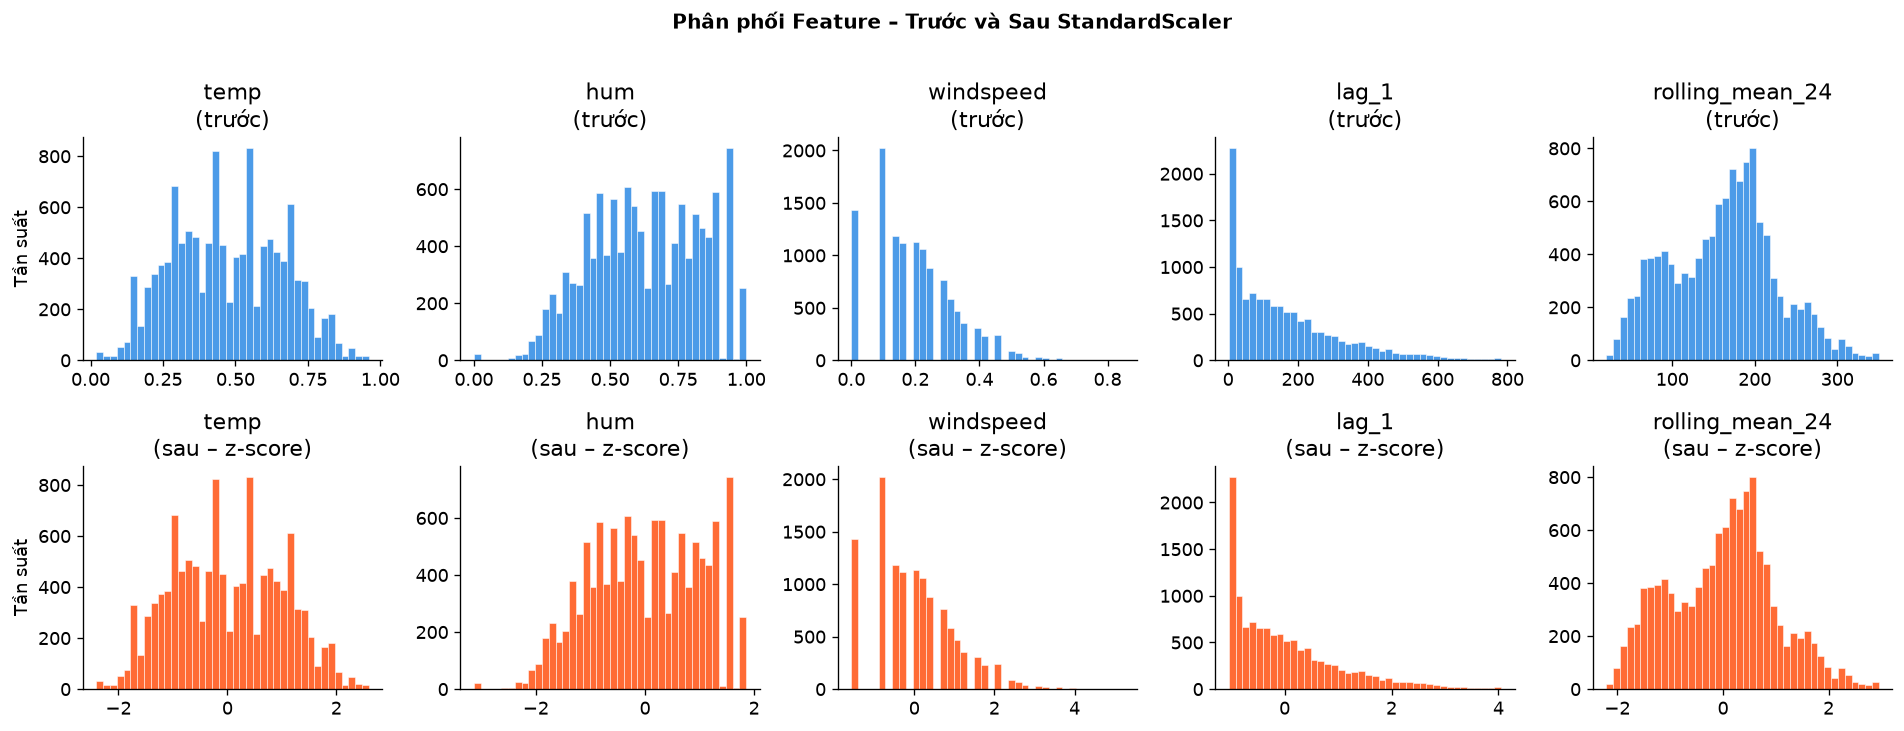

In [20]:
# Phân phối trước / sau chuẩn hóa
check_cols = ["temp", "hum", "windspeed", "lag_1", "rolling_mean_24"]

fig, axes = plt.subplots(2, len(check_cols), figsize=(16, 6))

for i, col in enumerate(check_cols):
    axes[0, i].hist(df_train_raw[col].dropna(), bins=40,
                    color="#4C9BE8", edgecolor="white", lw=0.3)
    axes[0, i].set_title(f"{col}\n(trước)")

    axes[1, i].hist(df_train[col].dropna(), bins=40,
                    color="#FF6B35", edgecolor="white", lw=0.3)
    axes[1, i].set_title(f"{col}\n(sau – z-score)")

axes[0, 0].set_ylabel("Tần suất")
axes[1, 0].set_ylabel("Tần suất")

plt.suptitle("Phân phối Feature – Trước và Sau StandardScaler",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_normalization_dist.png"), bbox_inches="tight")
plt.show()

## Cell 13 – Phân tích Tương quan

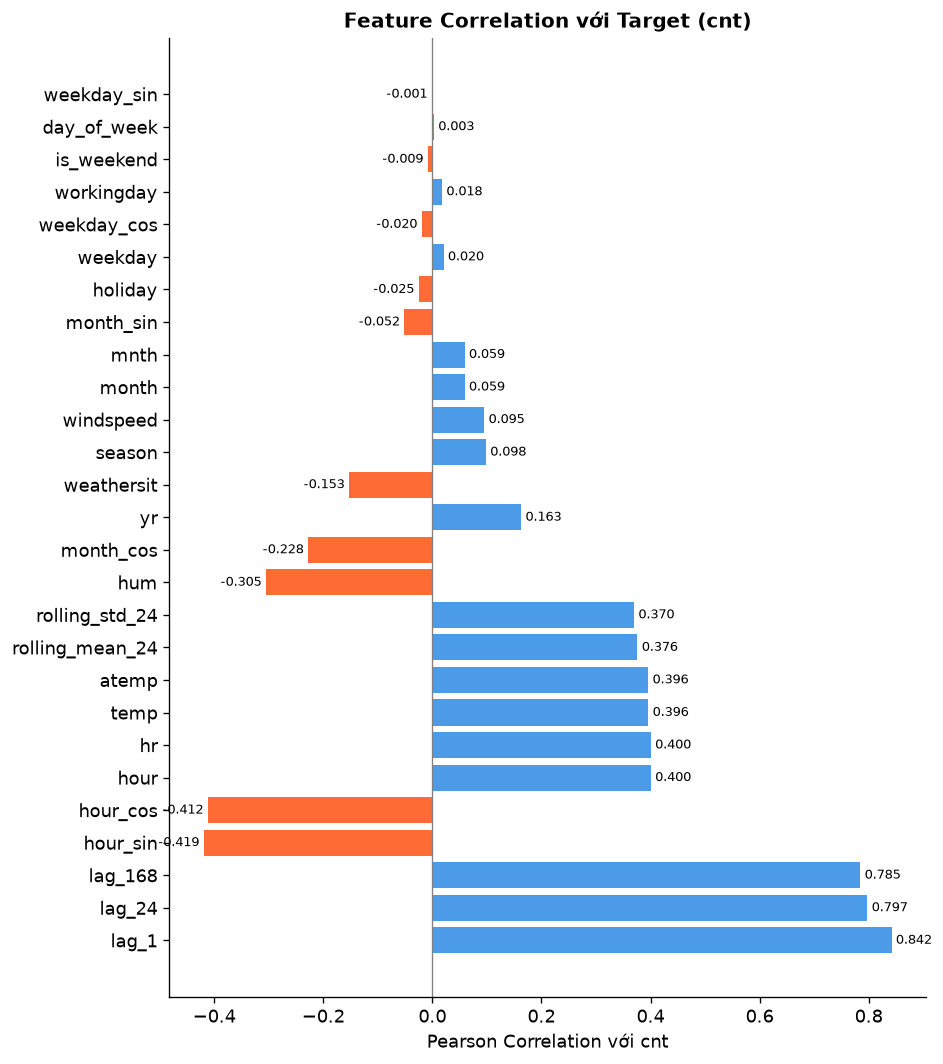


Top 10 features tương quan cao nhất:
lag_1              0.842
lag_24             0.797
lag_168            0.785
hour_sin          -0.419
hour_cos          -0.412
hour               0.400
hr                 0.400
temp               0.396
atemp              0.396
rolling_mean_24    0.376


In [21]:
# Correlation với target (dùng dữ liệu TRƯỚC chuẩn hóa để dễ đọc)
corr_target = (
    df_train_raw[feature_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#4C9BE8" if v >= 0 else "#FF6B35" for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("Pearson Correlation với cnt")
ax.set_title("Feature Correlation với Target (cnt)", fontsize=12, fontweight="bold")

for bar, val in zip(bars, corr_target.values):
    ax.text(val + 0.008 * np.sign(val),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_correlation_with_target.png"), bbox_inches="tight")
plt.show()

print("\nTop 10 features tương quan cao nhất:")
print(corr_target.head(10).round(3).to_string())

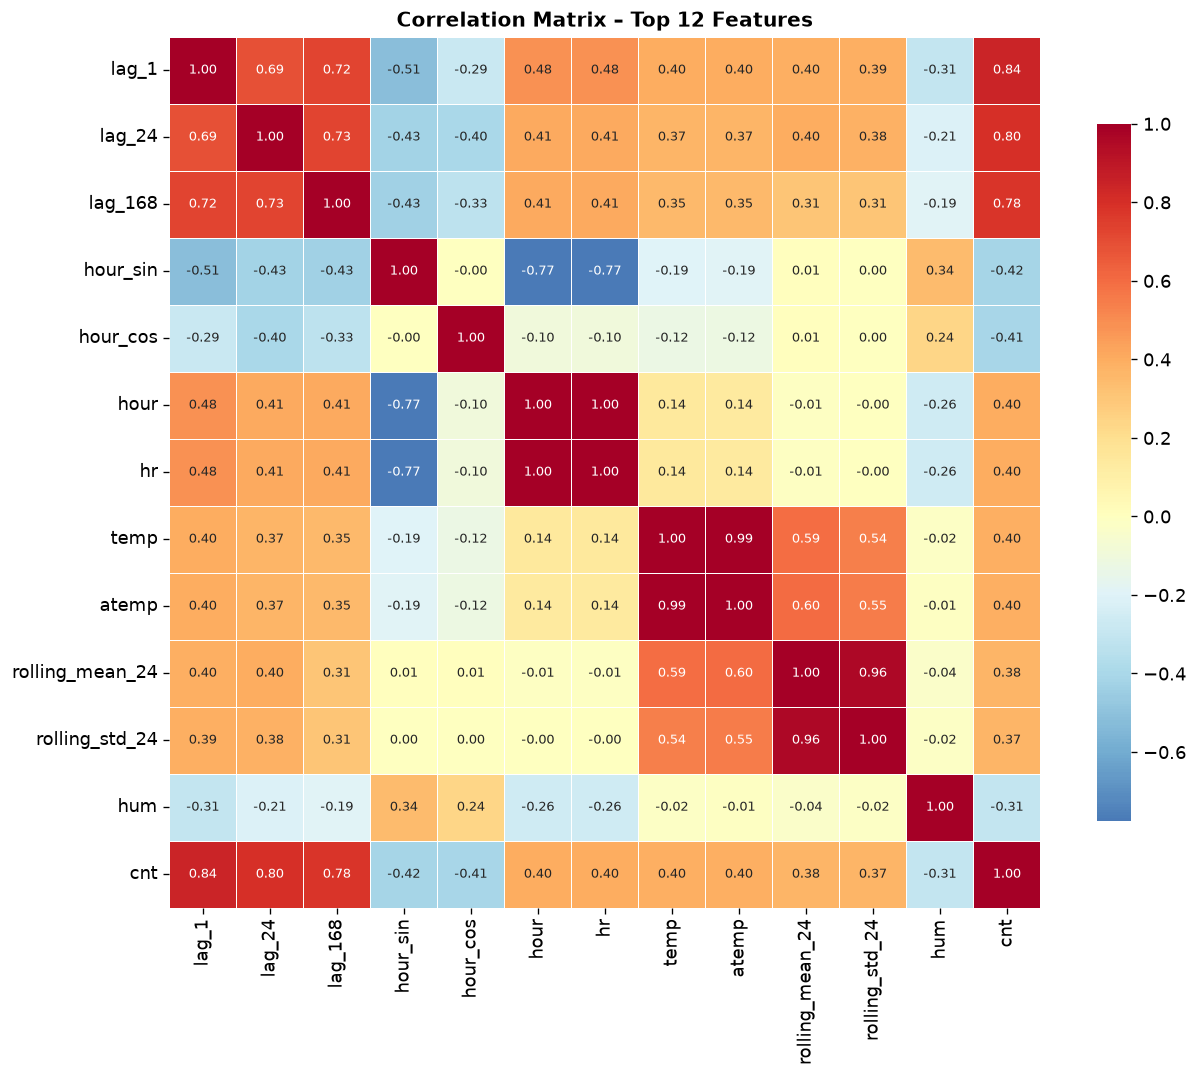

In [22]:
# Heatmap (top features)
top_feats = corr_target.head(12).index.tolist() + [TARGET]
corr_mat  = df_train_raw[top_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation Matrix – Top 12 Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fe_correlation_heatmap.png"), bbox_inches="tight")
plt.show()

## Cell 14 – Lưu file Processed

> **Lưu dữ liệu ở dạng giá trị GỐC** (chưa chuẩn hóa).  
> Xem giải thích chi tiết ở Cell 12 – mục "Lưu ý về file bike_sharing_processed.csv".

In [23]:
# Gán nhãn split (dùng bản TRƯỚC chuẩn hóa để lưu giá trị gốc)
df_train_raw = df_train_raw.copy(); df_train_raw["split"] = "train"
df_val_raw   = df_val_raw.copy();   df_val_raw["split"]   = "val"
df_test_raw  = df_test_raw.copy();  df_test_raw["split"]  = "test"

df_final = (
    pd.concat([df_train_raw, df_val_raw, df_test_raw], ignore_index=True)
    .sort_values("datetime")
    .reset_index(drop=True)
)

df_final.to_csv(PROCESSED_PATH, index=False)

print(f"✓ Đã lưu: {PROCESSED_PATH}")
print(f"  Shape  : {df_final.shape}")
print(f"  Columns: {list(df_final.columns)}")
print()
print("  Lưu ý: file này chứa giá trị GỐC (chưa chuẩn hóa).")
print("  Chuẩn hóa sẽ được thực hiện trong bước huấn luyện mô hình (03_models.ipynb)")
print("  để tránh data leakage (StandardScaler chỉ fit trên tập train).")

df_final.head()

✓ Đã lưu: C:\Users\ADMIN\Downloads\time-series-group-06-main\time-series-group-06-main\data\processed\bike_sharing_processed.csv
  Shape  : (17211, 30)
  Columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'datetime', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'split']

  Lưu ý: file này chứa giá trị GỐC (chưa chuẩn hóa).
  Chuẩn hóa sẽ được thực hiện trong bước huấn luyện mô hình (03_models.ipynb)
  để tránh data leakage (StandardScaler chỉ fit trên tập train).


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday_sin,weekday_cos,month_sin,month_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,split
0,1,0,1,7,0,6,0,2,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,2.0,84.0,16.0,63.250000,55.796408,train
1,1,0,1,8,0,6,0,3,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,9.0,210.0,40.0,60.125000,56.677050,train
2,1,0,1,9,0,6,0,3,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,15.0,134.0,32.0,52.000000,47.490045,train
3,1,0,1,10,0,6,0,2,0.18,0.1970,...,-0.974928,-0.222521,0.5,0.866025,20.0,63.0,13.0,47.250000,44.541383,train
4,1,0,1,11,0,6,0,2,0.20,0.1818,...,-0.974928,-0.222521,0.5,0.866025,61.0,67.0,2.0,47.166667,44.512496,train


## Cell 15 – Tổng Kết

In [24]:
n_total = len(df_final)
n_tr = (df_final["split"] == "train").sum()
n_va = (df_final["split"] == "val").sum()
n_te = (df_final["split"] == "test").sum()

print("═" * 62)
print("           TỔNG KẾT FEATURE ENGINEERING")
print("═" * 62)
print(f"  Dữ liệu thô          : {df_raw.shape}")
print(f"  Sau xử lý            : {df_final.shape}")
print(f"  Outlier treatment    : Winsorization Q1–Q99 trên 'cnt'")
print(f"  Rows bị drop (NaN)   : {len(df_raw) - n_total}  (do lag_168)")
print()
print("  Kiểm tra sampling regularity:")
print(f"    - Dữ liệu hourly, có ~165 timestamp bị thiếu trong 2 năm")
print(f"    - Lag/Rolling tính theo thứ tự hàng (không reindex)")
print()
print("  Features tạo mới:")
print("    Time     : hour, day_of_week, month, is_weekend")
print("    Fourier  : hour_sin, hour_cos, weekday_sin, weekday_cos,")
print("               month_sin, month_cos")
print("    Lag      : lag_1, lag_24, lag_168")
print("    Rolling  : rolling_mean_24, rolling_std_24")
print()
print(f"  Split (chronological, no shuffle):")
print(f"    Train  : {n_tr:>6,} rows  ({n_tr/n_total*100:.1f}%)")
print(f"    Val    : {n_va:>6,} rows  ({n_va/n_total*100:.1f}%)")
print(f"    Test   : {n_te:>6,} rows  ({n_te/n_total*100:.1f}%)")
print()
print("  Chuẩn hóa: StandardScaler (fit on train, transform all)")
print("  → File processed.csv lưu giá trị GỐC (chuẩn hóa ở bước model)")
print()
print("  Figures đã lưu:")
for fname in ["fe_outlier_boxplot", "fe_fourier_features", "fe_lag_scatter",
              "fe_rolling_features", "fe_train_val_test_split",
              "fe_normalization_dist", "fe_correlation_with_target",
              "fe_correlation_heatmap"]:
    fpath = os.path.join(FIGURES_DIR, fname + ".png")
    status = "✓" if os.path.exists(fpath) else "✗"
    print(f"    {status} figures/{fname}.png")
print()
print(f"  Processed data: data/processed/bike_sharing_processed.csv")
print("═" * 62)

══════════════════════════════════════════════════════════════
           TỔNG KẾT FEATURE ENGINEERING
══════════════════════════════════════════════════════════════
  Dữ liệu thô          : (17379, 17)
  Sau xử lý            : (17211, 30)
  Outlier treatment    : Winsorization Q1–Q99 trên 'cnt'
  Rows bị drop (NaN)   : 168  (do lag_168)

  Kiểm tra sampling regularity:
    - Dữ liệu hourly, có ~165 timestamp bị thiếu trong 2 năm
    - Lag/Rolling tính theo thứ tự hàng (không reindex)

  Features tạo mới:
    Time     : hour, day_of_week, month, is_weekend
    Fourier  : hour_sin, hour_cos, weekday_sin, weekday_cos,
               month_sin, month_cos
    Lag      : lag_1, lag_24, lag_168
    Rolling  : rolling_mean_24, rolling_std_24

  Split (chronological, no shuffle):
    Train  : 12,047 rows  (70.0%)
    Val    :  2,582 rows  (15.0%)
    Test   :  2,582 rows  (15.0%)

  Chuẩn hóa: StandardScaler (fit on train, transform all)
  → File processed.csv lưu giá trị GỐC (chuẩn hóa ở bước